In [1]:
from pathlib import Path 
import os
os.environ['MUJOCO_GL'] = 'egl'
os.environ['MKL_SERVICE_FORCE_INTEL'] = '1'
from tqdm import tqdm
from IPython.display import Video

import torch
import numpy as np

import sys
sys.path.append("/srv/sferraro/choreographer/")

import envs
from envs.make import make

import matplotlib.pyplot as plt
import matplotlib.animation as animation

import mani_skill2
import mani_skill2.envs


[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /home/elephant/miniconda3/envs/urlb/lib/python3.8/site-packages/robosuite-1.4.0-py3.8.egg/robosuite/scripts/setup_macros.py (__init__.py:9)


In [3]:
# Import agent model (WM + Actor Critic)
agent_path = Path(f'/srv/sferraro/choreographer/notebooks/object_pos_debug/models/ms/last_snapshot.pt')

def load_agent(agent_path):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    with agent_path.open('rb') as f:
        obj = torch.load(f, map_location=torch.device(device))
        agent = obj['agent']    
        step = obj['_global_step']
        agent.device = device
        agent.wm.device = device
        agent.wm.rssm.device = device
        agent.wm.rssm._cell.device = device
    return agent, step

agent, global_step = load_agent(agent_path)

In [4]:
from hydra import compose, initialize
from omegaconf import OmegaConf

initialize(config_path="../../exp_local/2023.05.10/144053_dreamer_obj_msPanda_CustomLift_/.hydra", job_name="config")
cfg = compose(config_name="config")

In [8]:
# Agent parametrization
obs_type = agent.cfg.obs_type
action_repeat = agent.cfg.action_repeat
snapshot_ts = global_step * action_repeat

agent.reward_free = True

agent.use_selector = False
agent.detached_exploration = True

seed = agent.cfg.seed

task = "msPanda_CustomLift"
domain = task.split("_")[0]

cfg.env.objects.minsize = 0.04
cfg.env.controller = "pd_joint_delta_pos"

# Env creation
eval_env = make(task, obs_type, frame_stack=1, 
                    action_repeat=action_repeat, seed=seed, env_config=cfg.env)

[2023-05-11 12:58:30.567] [svulkan2] [warning] A second renderer will share the same internal context with the first one. Arguments passed to constructor will be ignored.
/home/elephant/miniconda3/envs/urlb/lib/python3.8/site-packages/gym/spaces/box.py:73: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(


  0%|          | 0/1 [00:00<?, ?it/s]

Cube position: [ 0.00571987 -0.01829429  0.08572406]
Predicted position: [[ 0.28353631 -0.10466726  0.09902607]]
Pixels in view: 25


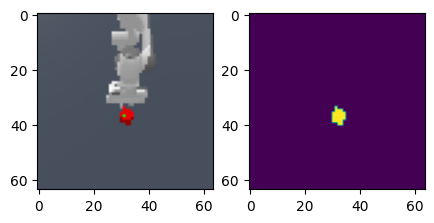

Cube position: [ 0.00571987 -0.01829429  0.08572406]
Predicted position: [[ 0.2695716  -0.11405957  0.09638038]]
Pixels in view: 24


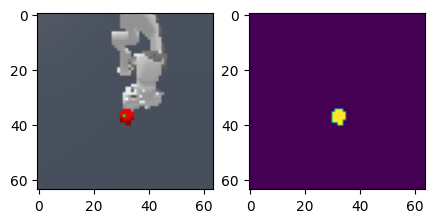

Cube position: [ 0.00571987 -0.01829429  0.08572406]
Predicted position: [[ 0.26102892 -0.11621218  0.10503125]]
Pixels in view: 24


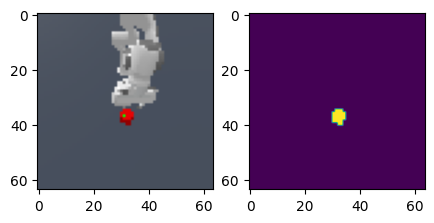

Cube position: [ 0.00571987 -0.01829429  0.08572406]
Predicted position: [[ 0.24728699 -0.10856356  0.08871847]]
Pixels in view: 22


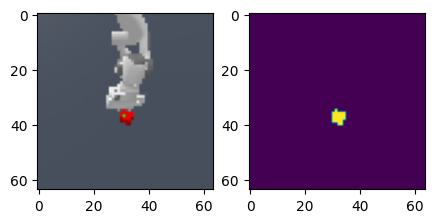

Cube position: [ 0.00571987 -0.01829429  0.08572406]
Predicted position: [[ 0.25907126 -0.11897371  0.089464  ]]
Pixels in view: 20


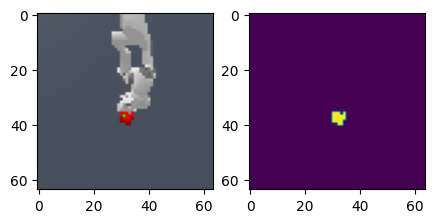

Cube position: [ 3.1852882e-02 -4.4408921e-16  9.6540123e-02]
Predicted position: [[ 0.26690263 -0.13636455  0.10185026]]
Pixels in view: 18


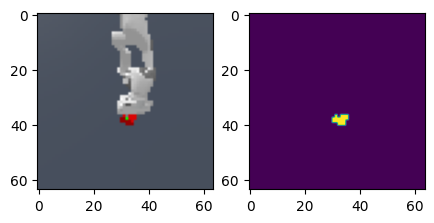

Cube position: [ 0.00621439 -0.01826355  0.08658828]
Predicted position: [[ 0.2653133  -0.1445906   0.11582113]]
Pixels in view: 19


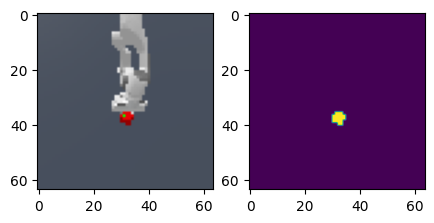

Cube position: [ 0.02602762 -0.01790081  0.08560289]
Predicted position: [[ 0.27065057 -0.13111669  0.10538456]]
Pixels in view: 13


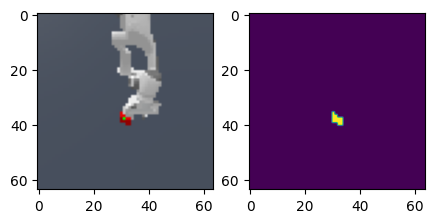

Cube position: [ 0.00572154 -0.01829419  0.08572698]
Predicted position: [[ 0.2657745  -0.13298371  0.11112943]]
Pixels in view: 20


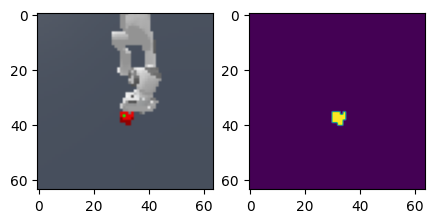

Cube position: [ 0.00674293 -0.03646139  0.08751193]
Predicted position: [[ 0.26967886 -0.121371    0.09686649]]
Pixels in view: 27


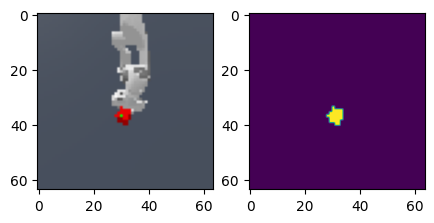

Cube position: [ 0.0298613  -0.07060129  0.09280082]
Predicted position: [[ 0.27898324 -0.10088969  0.09021503]]
Pixels in view: 27


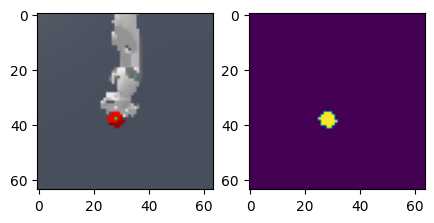

Cube position: [ 0.02685805 -0.08923274  0.08716207]
Predicted position: [[ 0.28255507 -0.08682515  0.08947818]]
Pixels in view: 29


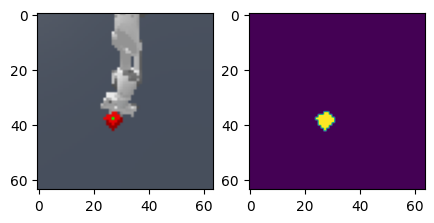

Cube position: [ 0.0297752  -0.10593569  0.09263917]
Predicted position: [[ 0.28965807 -0.0606576   0.09389347]]
Pixels in view: 28


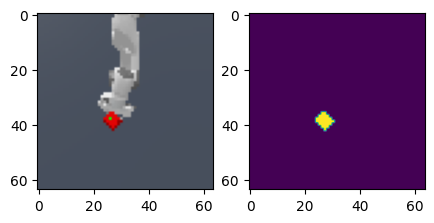

Cube position: [ 0.05216783 -0.08531722  0.09900595]
Predicted position: [[ 0.28606236 -0.07027768  0.10836829]]
Pixels in view: 26


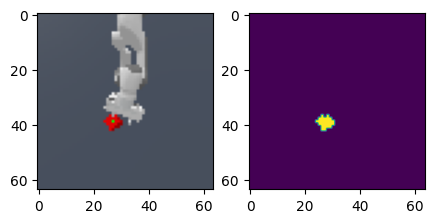

Cube position: [ 0.04658182 -0.08724022  0.08771381]
Predicted position: [[ 0.28843302 -0.04525244  0.11715369]]
Pixels in view: 13


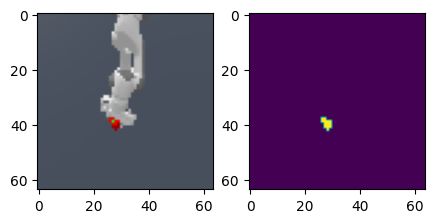

Cube position: [ 0.04658182 -0.08724022  0.08771381]
Predicted position: [[ 0.28492352 -0.08553068  0.11858878]]
Pixels in view: 8


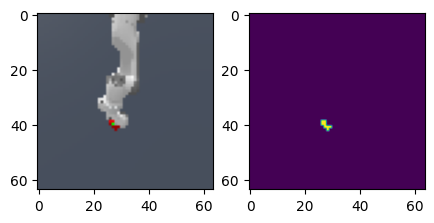

Cube position: [ 0.04658182 -0.08724022  0.08771381]
Predicted position: [[ 0.27916592 -0.09665151  0.12319468]]
Pixels in view: 8


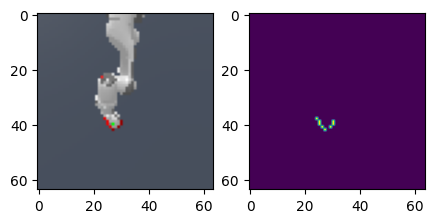

Cube position: [ 0.1066077  -0.06657607  0.20905644]
Predicted position: [[ 0.28156808 -0.10311449  0.11815153]]
Pixels in view: 14


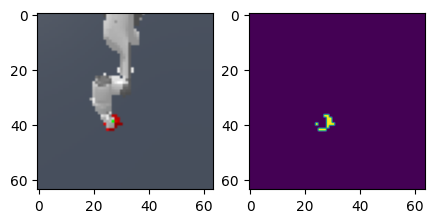

Cube position: [ 0.1066077  -0.06657607  0.20905644]
Predicted position: [[ 0.28332555 -0.10275004  0.11532703]]
Pixels in view: 6


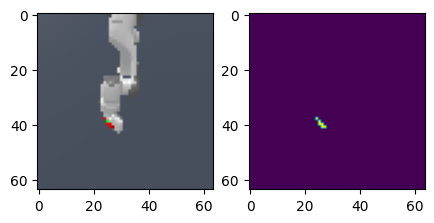

Cube position: [ 0.1066077  -0.06657607  0.20905644]
Predicted position: [[ 0.2812689  -0.10348573  0.12226158]]
Pixels in view: 11


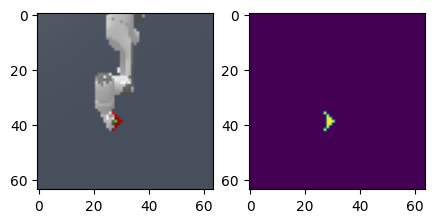

Cube position: [ 0.1066077  -0.06657607  0.20905644]
Predicted position: [[ 0.28563595 -0.10449236  0.10841462]]
Pixels in view: 10


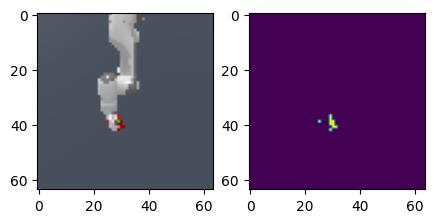

Cube position: [ 0.1066077  -0.06657607  0.20905644]
Predicted position: [[ 0.2906962  -0.10578776  0.10251328]]
Pixels in view: 10


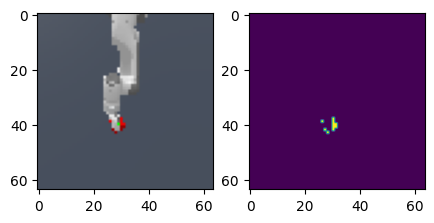

Cube position: [ 0.06412887 -0.08581319  0.0853721 ]
Predicted position: [[ 0.29481882 -0.1072887   0.09916031]]
Pixels in view: 20


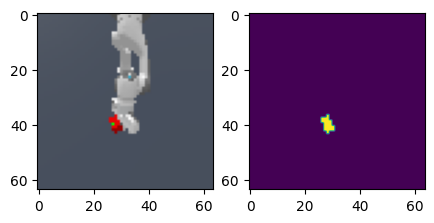

Cube position: [ 0.06415012 -0.08580546  0.08541846]
Predicted position: [[ 0.29676676 -0.10256924  0.09125932]]
Pixels in view: 12


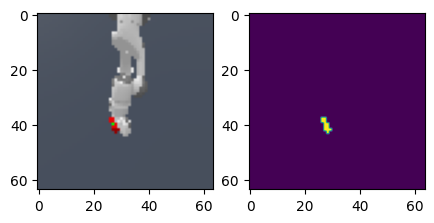

Cube position: [ 0.05987719 -0.06613059  0.11459047]
Predicted position: [[ 0.29475886 -0.0864544   0.09441478]]
Pixels in view: 20


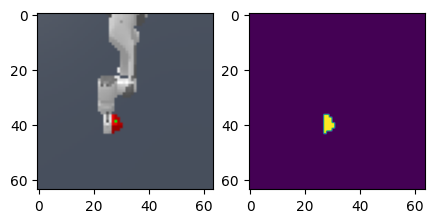

Cube position: [ 0.14042258 -0.06966777  0.2518311 ]
Predicted position: [[ 0.2944776  -0.11047755  0.09701087]]
Pixels in view: 15


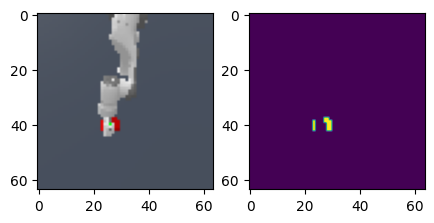

Cube position: [ 0.07444797 -0.13129432  0.10788652]
Predicted position: [[ 0.29823047 -0.12834984  0.0905585 ]]
Pixels in view: 27


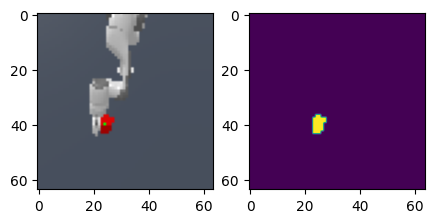

Cube position: [ 0.07204399 -0.1326937   0.10264145]
Predicted position: [[ 0.29533994 -0.14464194  0.0952472 ]]
Pixels in view: 31


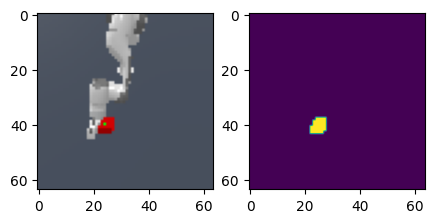

Cube position: [ 0.08997183 -0.12962279  0.10402989]
Predicted position: [[ 0.29660368 -0.15473437  0.09438643]]
Pixels in view: 31


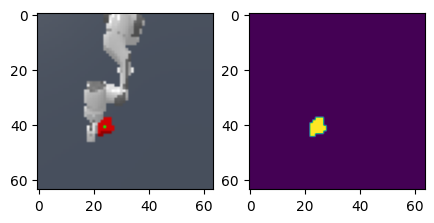

Cube position: [ 0.07548706 -0.14702566  0.11015361]
Predicted position: [[ 0.2953685  -0.13804942  0.09364543]]
Pixels in view: 31


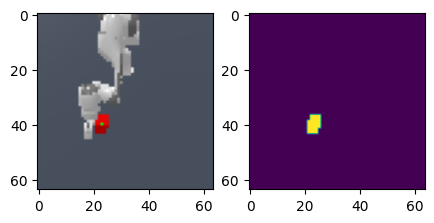

Cube position: [ 0.07602492 -0.14667343  0.11132712]
Predicted position: [[ 0.28882343 -0.10714322  0.10617463]]
Pixels in view: 33


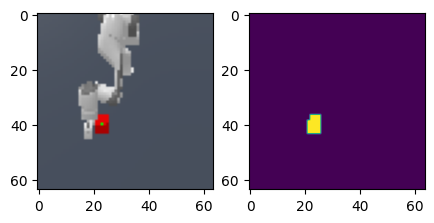

Cube position: [ 0.08594503 -0.132108    0.09452081]
Predicted position: [[ 0.29220885 -0.13274658  0.10163441]]
Pixels in view: 22


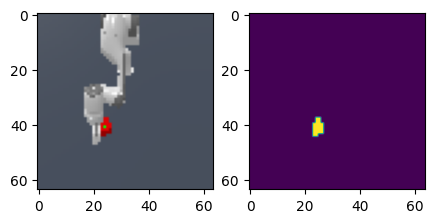

Cube position: [ 0.07012494 -0.15053712  0.09845444]
Predicted position: [[ 0.29166514 -0.12330894  0.09980303]]
Pixels in view: 23


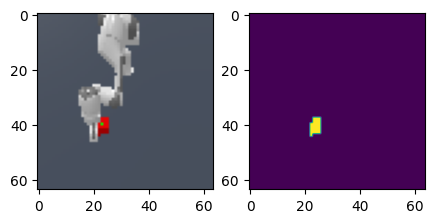

Cube position: [ 0.06874514 -0.13461396  0.09544396]
Predicted position: [[ 0.29071775 -0.11052304  0.10003901]]
Pixels in view: 27


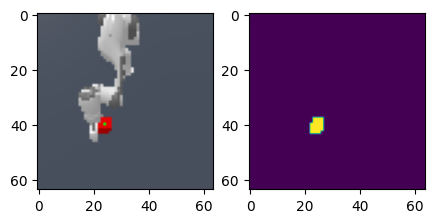

Cube position: [ 0.0680872  -0.11812233  0.09400845]
Predicted position: [[ 0.2873807  -0.09836013  0.11130863]]
Pixels in view: 23


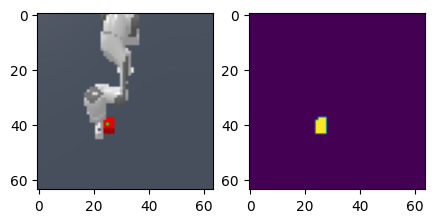

Cube position: [ 0.06537241 -0.11950508  0.08808528]
Predicted position: [[ 0.28850833 -0.09679615  0.10388435]]
Pixels in view: 22


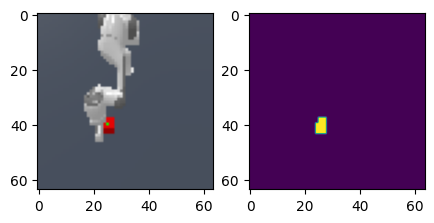

Cube position: [ 0.06622112 -0.085052    0.089937  ]
Predicted position: [[ 0.28476405 -0.09068374  0.11684969]]
Pixels in view: 15


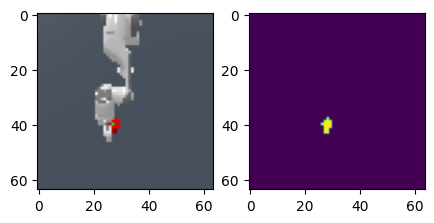

Cube position: [ 0.06622112 -0.085052    0.089937  ]
Predicted position: [[ 0.28876907 -0.09337125  0.1070466 ]]
Pixels in view: 12


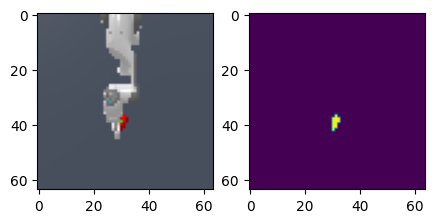

Cube position: [ 0.06622112 -0.085052    0.089937  ]
Predicted position: [[ 0.29519862 -0.09809861  0.10439903]]
Pixels in view: 6


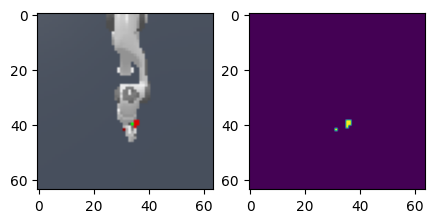

Cube position: [ 0.06622112 -0.085052    0.089937  ]
Predicted position: [[ 0.29804066 -0.12563846  0.10364135]]
Pixels in view: 7


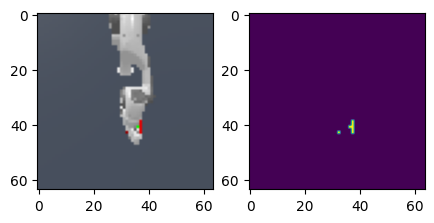

Cube position: [ 0.06622112 -0.085052    0.089937  ]
Predicted position: [[ 0.2984635  -0.12028491  0.0966101 ]]
Pixels in view: 7


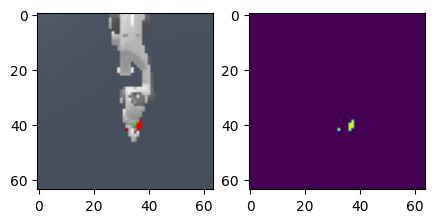

Cube position: [ 0.06622112 -0.085052    0.089937  ]
Predicted position: [[ 0.29917163 -0.10235976  0.08746672]]
Pixels in view: 5


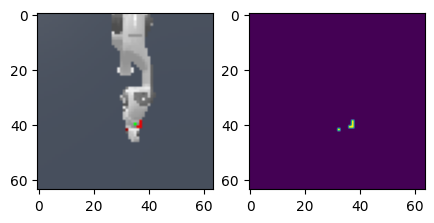

Cube position: [ 0.06622112 -0.085052    0.089937  ]
Predicted position: [[ 0.30236048 -0.09067058  0.09212352]]
Pixels in view: 2


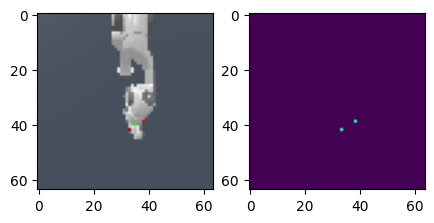

Cube position: [ 0.06622112 -0.085052    0.089937  ]
Predicted position: [[ 0.29525566 -0.07124025  0.0990514 ]]
Pixels in view: 11


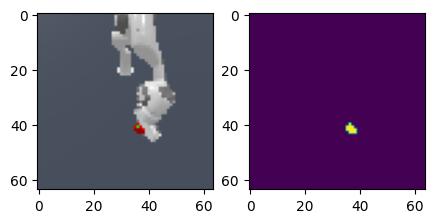

Cube position: [ 0.06622112 -0.085052    0.089937  ]
Predicted position: [[ 0.2967401  -0.07330288  0.08893461]]
Pixels in view: 11


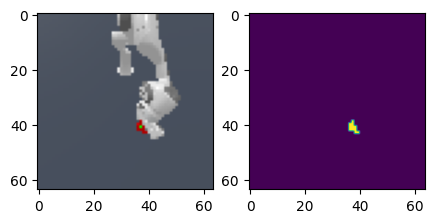

Cube position: [ 0.06622112 -0.085052    0.089937  ]
Predicted position: [[ 0.29955631 -0.08844617  0.08548173]]
Pixels in view: 10


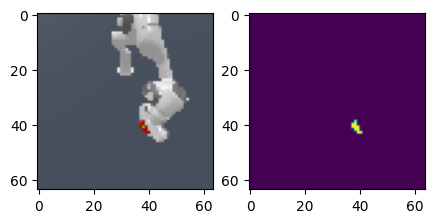

Cube position: [ 0.06622112 -0.085052    0.089937  ]
Predicted position: [[ 0.29321212 -0.11688326  0.09632292]]
Pixels in view: 2


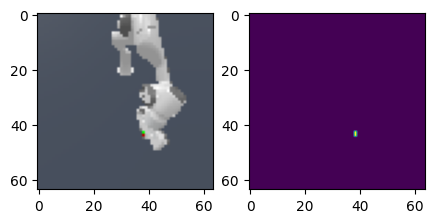

Cube position: [ 0.06622112 -0.085052    0.089937  ]
Predicted position: [[ 0.29433888 -0.09450103  0.09073246]]
Pixels in view: 7


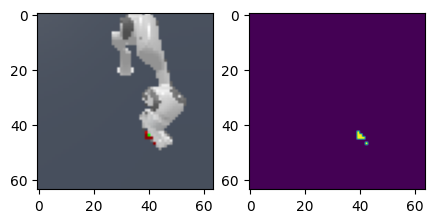

Cube position: [ 0.06622112 -0.085052    0.089937  ]
Predicted position: [[ 0.29390132 -0.06656758  0.09321814]]
Pixels in view: 11


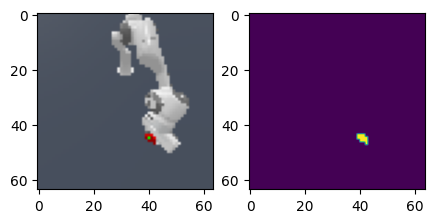

Cube position: [ 0.06622112 -0.085052    0.089937  ]
Predicted position: [[ 0.29134762 -0.07147685  0.09254587]]
Pixels in view: 12


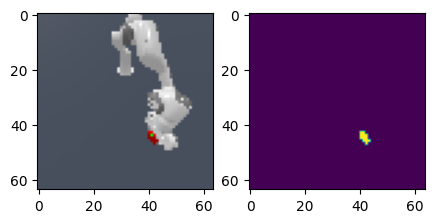

Cube position: [ 0.06622112 -0.085052    0.089937  ]
Predicted position: [[ 0.28730038 -0.0659074   0.10464169]]
Pixels in view: 2


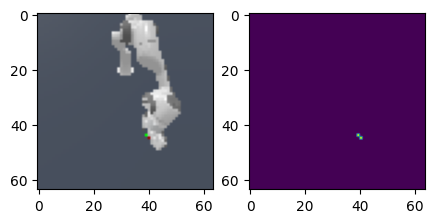

Cube position: [ 0.06622112 -0.085052    0.089937  ]
Predicted position: [[ 0.28845572 -0.09214047  0.10530673]]
Pixels in view: 2


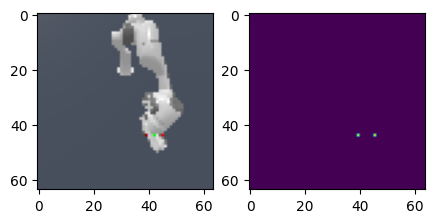

Cube position: [ 0.06622112 -0.085052    0.089937  ]
Predicted position: [[ 0.28308934 -0.09785634  0.11532374]]
Pixels in view: 4


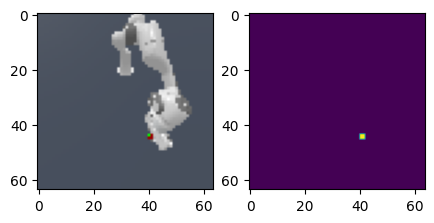

Cube position: [ 0.06622112 -0.085052    0.089937  ]
Predicted position: [[ 0.27860525 -0.10812571  0.114739  ]]
Pixels in view: 3


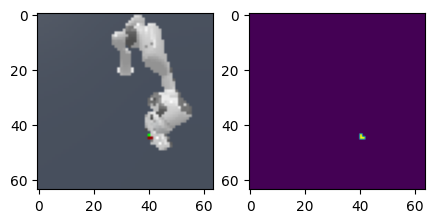

Cube position: [ 0.06622112 -0.085052    0.089937  ]
Predicted position: [[ 0.2726284  -0.12415046  0.13679495]]
Pixels in view: 10


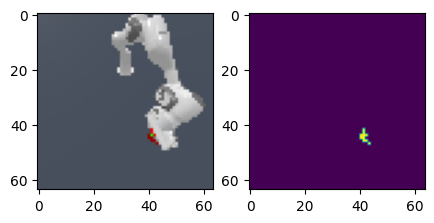

Cube position: [0.13339171 0.15688434 0.09037467]
Predicted position: [[ 0.28133798 -0.1213466   0.11286931]]
Pixels in view: 26


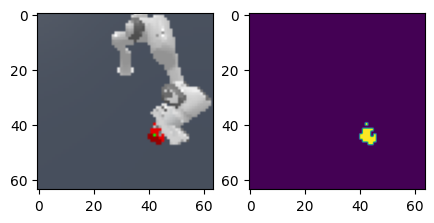

Cube position: [0.10577993 0.17538163 0.10199986]
Predicted position: [[ 0.28366974 -0.11708006  0.10751061]]
Pixels in view: 31


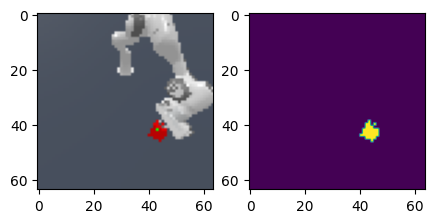

Cube position: [0.13246678 0.1577553  0.08754545]
Predicted position: [[ 0.28267658 -0.11120277  0.10211814]]
Pixels in view: 22


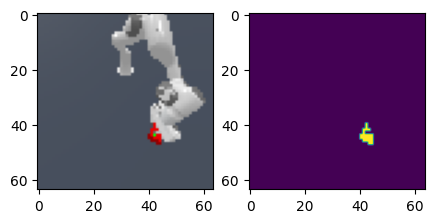

Cube position: [0.13331583 0.1569558  0.09014257]
Predicted position: [[ 0.28462613 -0.12879115  0.10267432]]
Pixels in view: 28


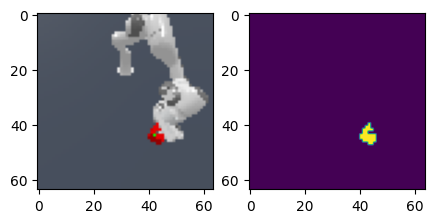

Cube position: [0.13606201 0.16980688 0.09854265]
Predicted position: [[ 0.28439873 -0.12881674  0.10709502]]
Pixels in view: 30


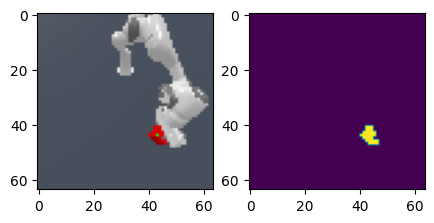

Cube position: [0.13489236 0.1710184  0.09496487]
Predicted position: [[ 0.28415695 -0.13133797  0.10640129]]
Pixels in view: 27


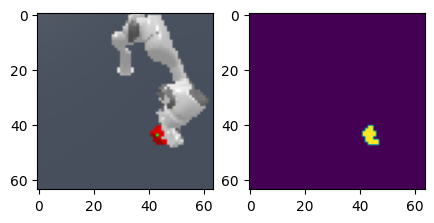

Cube position: [0.13900818 0.1819148  0.10755444]
Predicted position: [[ 0.28132552 -0.10351942  0.1165873 ]]
Pixels in view: 32


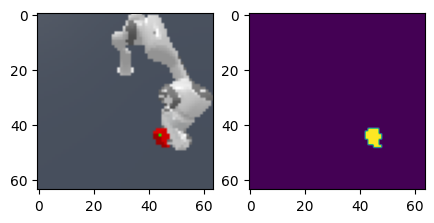

Cube position: [0.1446856  0.20474945 0.1249207 ]
Predicted position: [[ 0.27350825 -0.11731124  0.13218959]]
Pixels in view: 45


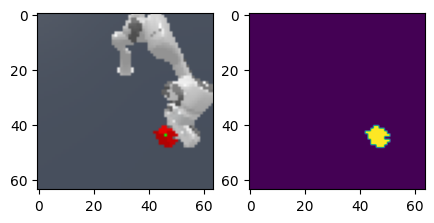

Cube position: [0.1414789  0.2089768  0.11511197]
Predicted position: [[ 0.27357835 -0.10822708  0.12700653]]
Pixels in view: 45


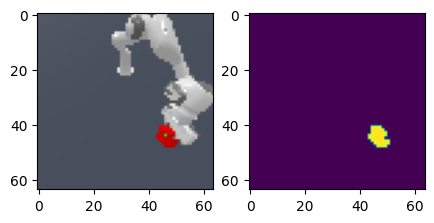

Cube position: [0.15152404 0.18108761 0.10036665]
Predicted position: [[ 0.2666149  -0.07515488  0.13018832]]
Pixels in view: 24


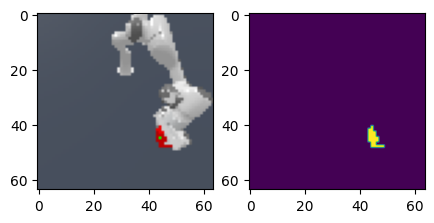

Cube position: [0.1542265  0.19260755 0.10946061]
Predicted position: [[ 0.26362902 -0.1175996   0.1317398 ]]
Pixels in view: 40


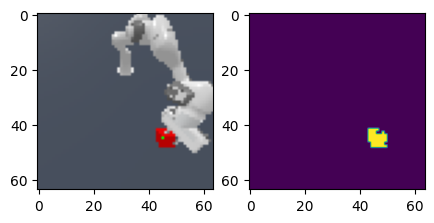

Cube position: [0.16330995 0.21126564 0.0909474 ]
Predicted position: [[ 0.27515006 -0.12461592  0.11856884]]
Pixels in view: 49


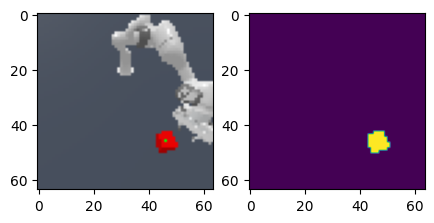

Cube position: [0.1758552  0.20997742 0.08468203]
Predicted position: [[ 0.2821473  -0.132072    0.11632603]]
Pixels in view: 45


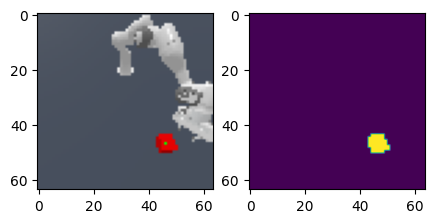

Cube position: [0.1758552  0.20997742 0.08468203]
Predicted position: [[ 0.28519785 -0.1210511   0.12020887]]
Pixels in view: 45


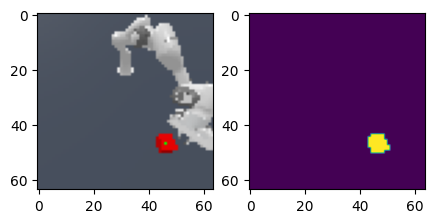

Cube position: [0.17585313 0.2099809  0.08467345]
Predicted position: [[ 0.2762185  -0.13619941  0.13107899]]
Pixels in view: 43


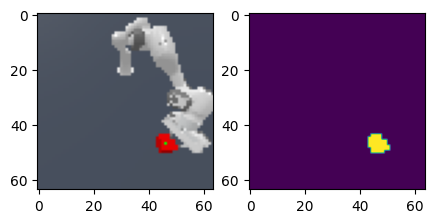

Cube position: [0.1674443  0.23414358 0.10634436]
Predicted position: [[ 0.2685387  -0.1373612   0.13871849]]
Pixels in view: 46


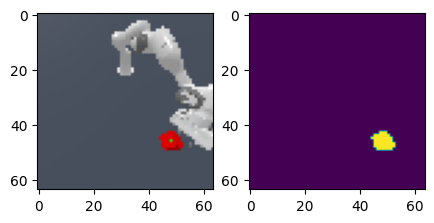

Cube position: [0.16595562 0.2515715  0.10080028]
Predicted position: [[ 0.28269836 -0.13320482  0.12304112]]
Pixels in view: 41


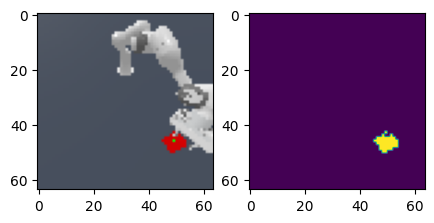

Cube position: [0.16462336 0.23912644 0.09583878]
Predicted position: [[ 0.28680617 -0.1458041   0.10681594]]
Pixels in view: 48


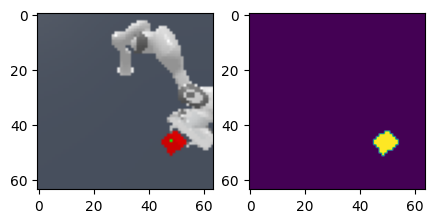

Cube position: [0.17699122 0.20805596 0.08939756]
Predicted position: [[ 0.28715384 -0.15190504  0.10873283]]
Pixels in view: 35


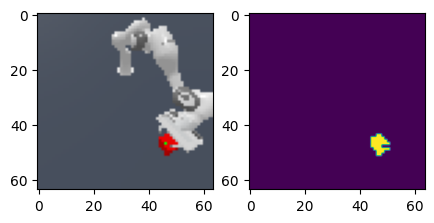

Cube position: [0.18992586 0.20557201 0.08632074]
Predicted position: [[ 0.28300968 -0.14559762  0.10710931]]
Pixels in view: 24


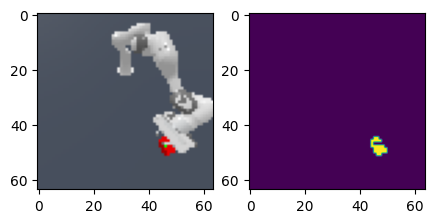

Cube position: [0.17747805 0.22203489 0.09141834]
Predicted position: [[ 0.29122147 -0.16652727  0.09939902]]
Pixels in view: 40


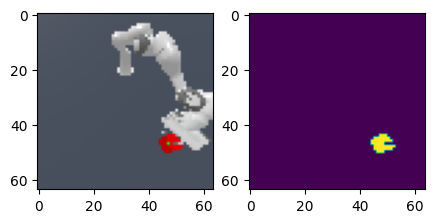

Cube position: [0.16664465 0.2355561  0.10336631]
Predicted position: [[ 0.29767692 -0.1271285   0.08663075]]
Pixels in view: 45


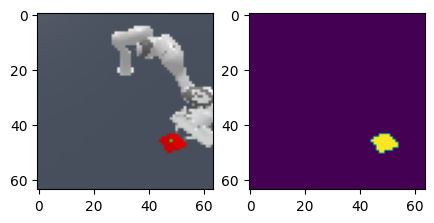

Cube position: [0.17668489 0.22347225 0.08812597]
Predicted position: [[ 0.30144113 -0.13558573  0.08835741]]
Pixels in view: 42


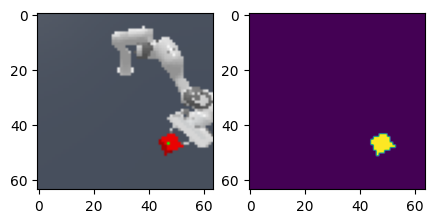

Cube position: [0.17797863 0.22112769 0.09349629]
Predicted position: [[ 0.2978039  -0.1528106   0.09477811]]
Pixels in view: 42


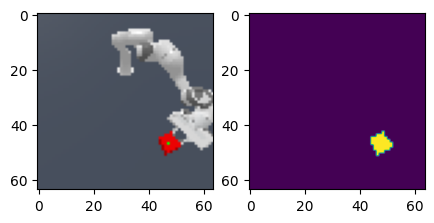

Cube position: [0.16604894 0.22182032 0.10114781]
Predicted position: [[ 0.30980647 -0.15745664  0.08986432]]
Pixels in view: 49


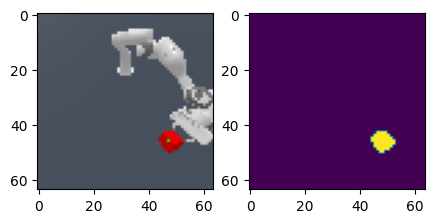

Cube position: [0.16786195 0.23340586 0.10789975]
Predicted position: [[ 0.30603653 -0.16362184  0.09252183]]
Pixels in view: 50


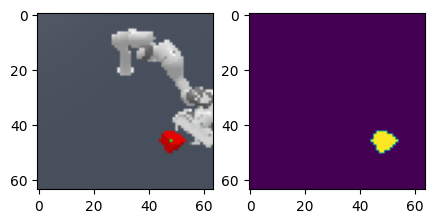

Cube position: [0.16344419 0.2562849  0.0914474 ]
Predicted position: [[ 0.30931246 -0.14478725  0.08888205]]
Pixels in view: 40


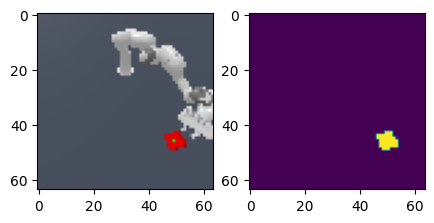

Cube position: [0.1472555  0.29496503 0.08600266]
Predicted position: [[ 0.308574   -0.1609712   0.09716944]]
Pixels in view: 44


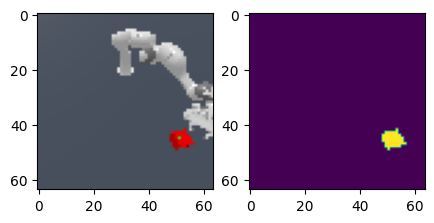

Cube position: [0.14691953 0.29561383 0.0848721 ]
Predicted position: [[ 0.30101973 -0.15272762  0.09934193]]
Pixels in view: 43


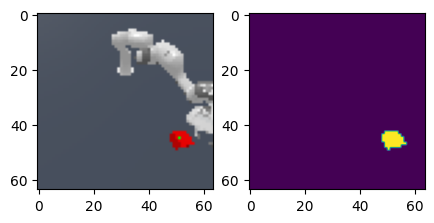

Cube position: [0.14691953 0.29561383 0.0848721 ]
Predicted position: [[ 0.30436182 -0.12598905  0.09198849]]
Pixels in view: 36


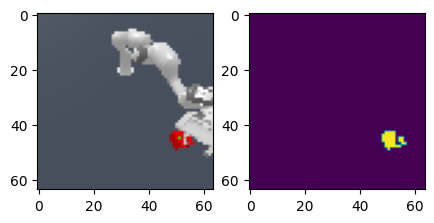

Cube position: [0.14691953 0.29561383 0.0848721 ]
Predicted position: [[ 0.29753593 -0.15634477  0.09724481]]
Pixels in view: 6


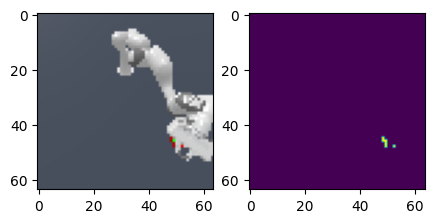

Cube position: [0.14691953 0.29561383 0.0848721 ]
Predicted position: [[ 0.2880574  -0.2030423   0.12288227]]
Pixels in view: 3


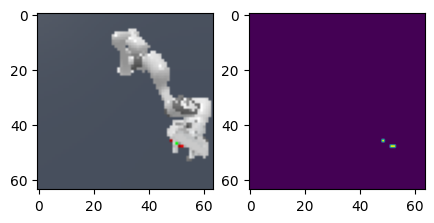

Cube position: [0.14691953 0.29561383 0.0848721 ]
Predicted position: [[ 0.29490212 -0.2324411   0.12526137]]
Pixels in view: 9


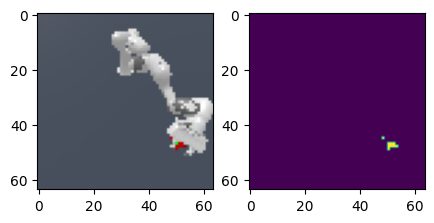

Cube position: [0.14691953 0.29561383 0.0848721 ]
Predicted position: [[ 0.29736304 -0.21378696  0.1183103 ]]
Pixels in view: 7


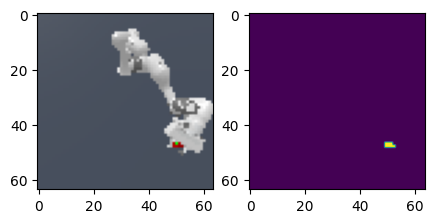

Cube position: [0.1469172  0.28005946 0.08486426]
Predicted position: [[ 0.27969062 -0.26137128  0.15389289]]
Pixels in view: 34


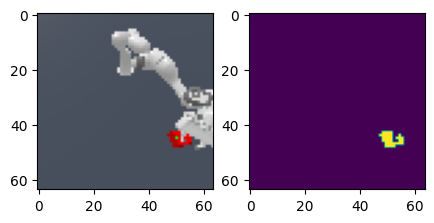

Cube position: [0.1469172  0.28005946 0.08486426]
Predicted position: [[ 0.29505444 -0.26356074  0.10730106]]
Pixels in view: 34


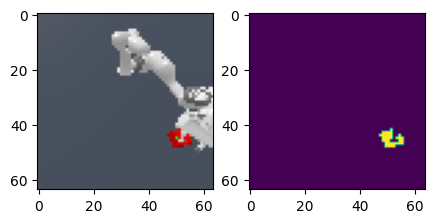

Cube position: [0.16593724 0.23163725 0.14886823]
Predicted position: [[ 0.298393   -0.24263605  0.10658713]]
Pixels in view: 21


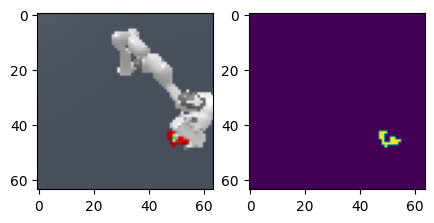

Cube position: [0.12736857 0.2926007  0.07195095]
Predicted position: [[ 0.29755533 -0.25941342  0.11669423]]
Pixels in view: 30


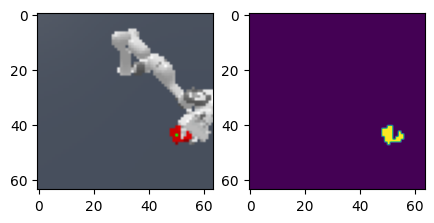

Cube position: [0.11994782 0.30006894 0.09684051]
Predicted position: [[ 0.29271117 -0.28105482  0.12839726]]
Pixels in view: 35


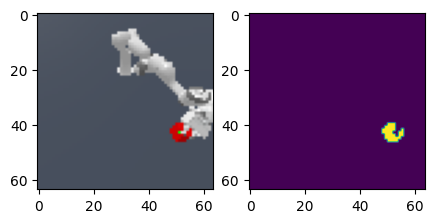

Cube position: [0.11970051 0.30048108 0.0961494 ]
Predicted position: [[ 0.2944246  -0.28952473  0.13317087]]
Pixels in view: 40


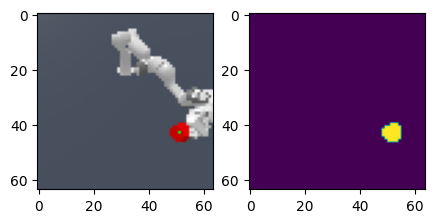

Cube position: [0.11603133 0.27432278 0.08589579]
Predicted position: [[ 0.2923026  -0.28808415  0.13304892]]
Pixels in view: 31


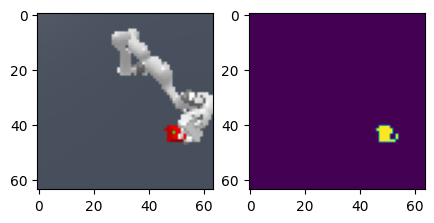

Cube position: [0.11871848 0.27031586 0.09340509]
Predicted position: [[ 0.2779012  -0.31104735  0.17482974]]
Pixels in view: 39


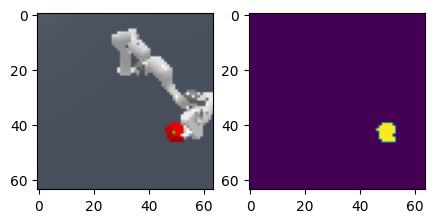

Cube position: [0.11595794 0.2744322  0.0856907 ]
Predicted position: [[ 0.2734272  -0.30986282  0.18231596]]
Pixels in view: 34


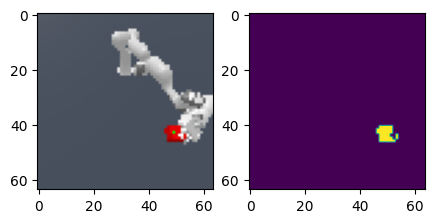

Cube position: [0.11572012 0.25862288 0.08502612]
Predicted position: [[ 0.27069238 -0.3197256   0.19312826]]
Pixels in view: 30


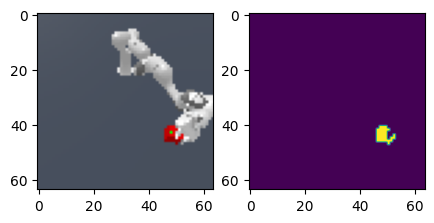

Cube position: [0.11728968 0.25642014 0.08941226]
Predicted position: [[ 0.25307596 -0.33576185  0.22799896]]
Pixels in view: 34


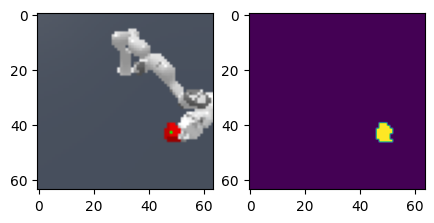

Cube position: [0.10205745 0.27623925 0.09245502]
Predicted position: [[ 0.2473864  -0.35908562  0.24057823]]
Pixels in view: 32


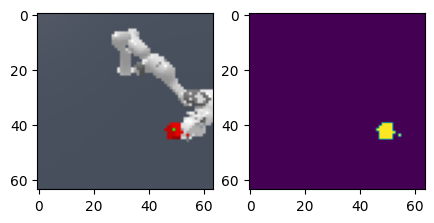

Cube position: [0.09920236 0.26373994 0.08513427]
Predicted position: [[ 0.2561489  -0.34327805  0.22436936]]
Pixels in view: 30


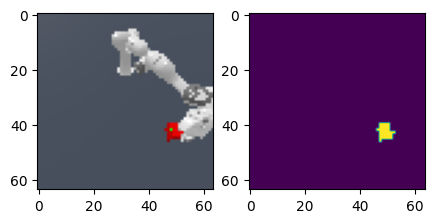

Cube position: [0.09920236 0.26373994 0.08513427]
Predicted position: [[ 0.25326043 -0.33383363  0.23102714]]
Pixels in view: 30


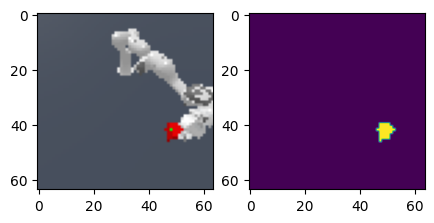

Cube position: [0.09924054 0.2636898  0.08523218]
Predicted position: [[ 0.24876255 -0.36394027  0.24392508]]
Pixels in view: 28


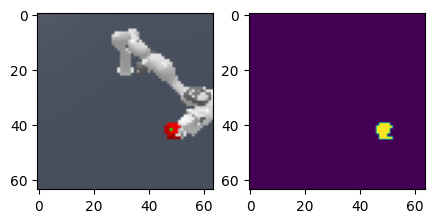

Cube position: [0.08240155 0.26858985 0.08615308]
Predicted position: [[ 0.24600966 -0.37490568  0.23962544]]
Pixels in view: 32


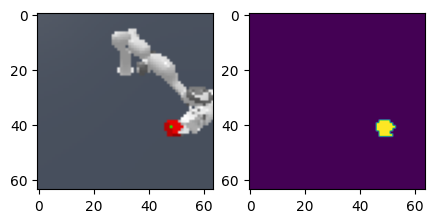

Cube position: [0.10312288 0.2585905  0.09518689]
Predicted position: [[ 0.25156215 -0.34616396  0.2389139 ]]
Pixels in view: 30


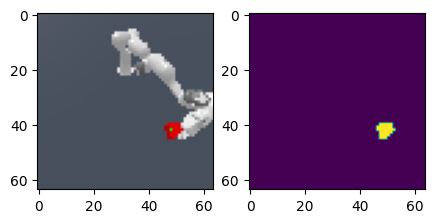

Cube position: [0.10617007 0.25458813 0.10300019]
Predicted position: [[ 0.2478022 -0.3365694  0.2547605]]
Pixels in view: 27


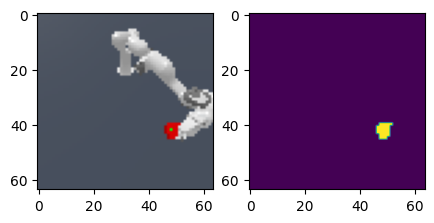

Cube position: [0.1045451  0.2727676  0.09883362]
Predicted position: [[ 0.23514923 -0.3134228   0.2714805 ]]
Pixels in view: 42


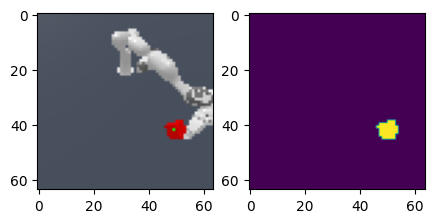

Cube position: [0.09393844 0.28614312 0.11339682]
Predicted position: [[ 0.25132495 -0.300491    0.24064796]]
Pixels in view: 41


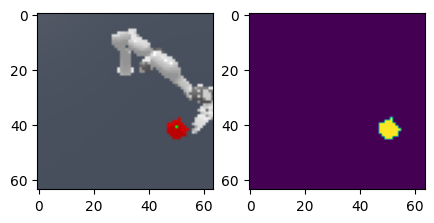

Cube position: [0.09179176 0.2730616  0.10832756]
Predicted position: [[ 0.26448572 -0.26676422  0.22770712]]
Pixels in view: 37


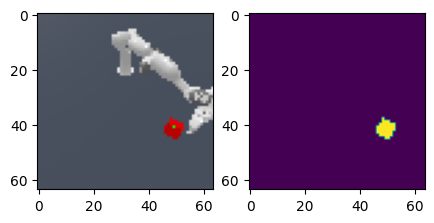

Cube position: [0.0993831  0.26350254 0.08559772]
Predicted position: [[ 0.25899592 -0.27298167  0.24862312]]
Pixels in view: 38


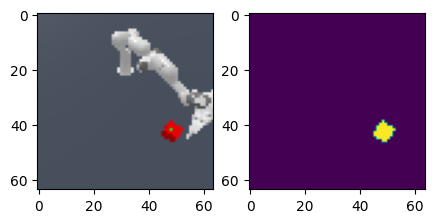

Cube position: [0.09920086 0.2637419  0.08513043]
Predicted position: [[ 0.25482947 -0.279177    0.25517625]]
Pixels in view: 38


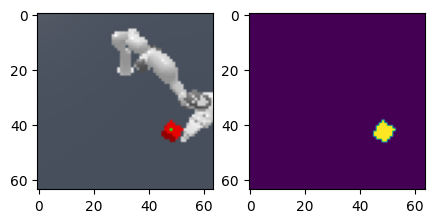

Cube position: [0.10025603 0.24595873 0.087836  ]
Predicted position: [[ 0.25470924 -0.27792585  0.26445222]]
Pixels in view: 32


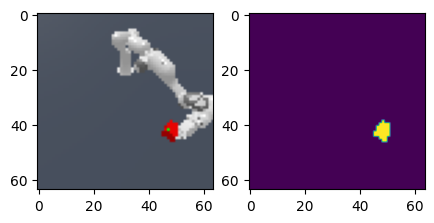

Cube position: [0.10004719 0.2462159  0.08730052]
Predicted position: [[ 0.25278047 -0.30124444  0.2547962 ]]
Pixels in view: 28


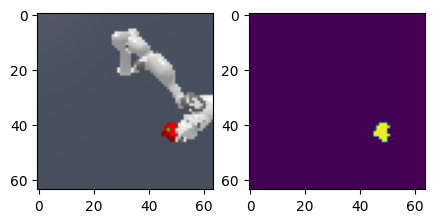

Cube position: [0.10141952 0.24452604 0.09081931]
Predicted position: [[ 0.23890935 -0.3407971   0.27982095]]
Pixels in view: 22


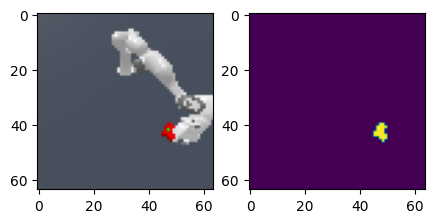

Cube position: [0.10141952 0.24452604 0.09081931]
Predicted position: [[ 0.22094387 -0.38081867  0.29018044]]
Pixels in view: 16


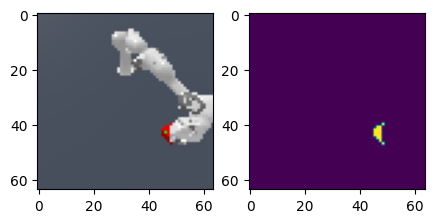

Cube position: [0.10141952 0.24452604 0.09081931]
Predicted position: [[ 0.21277378 -0.37538618  0.30192024]]
Pixels in view: 12


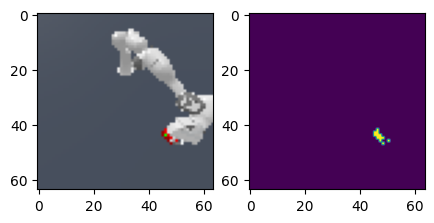

Cube position: [0.11616995 0.24186711 0.08628318]
Predicted position: [[ 0.21289325 -0.38417357  0.28817797]]
Pixels in view: 22


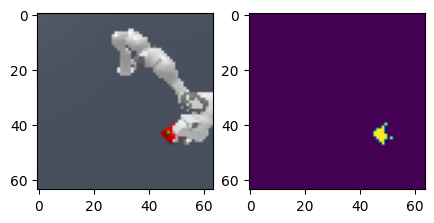

Cube position: [0.11462658 0.2601576  0.0819702 ]
Predicted position: [[ 0.21892133 -0.38175148  0.26324326]]
Pixels in view: 28


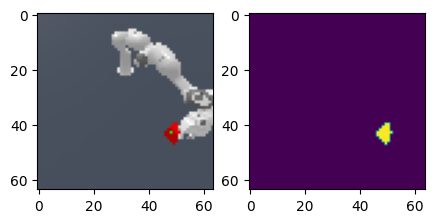

Cube position: [0.09929168 0.2471462  0.08536332]
Predicted position: [[ 0.22386166 -0.3767106   0.24037674]]
Pixels in view: 22


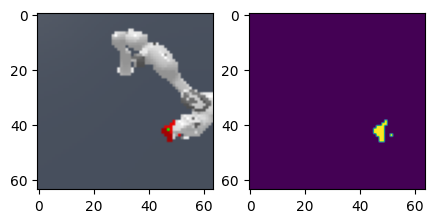

Cube position: [0.09929168 0.2471462  0.08536332]
Predicted position: [[ 0.21607599 -0.34993905  0.26139182]]
Pixels in view: 18


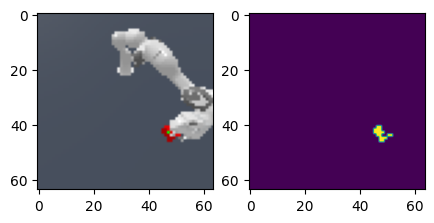

Cube position: [0.09929168 0.2471462  0.08536332]
Predicted position: [[ 0.20939057 -0.29961964  0.25412136]]
Pixels in view: 19


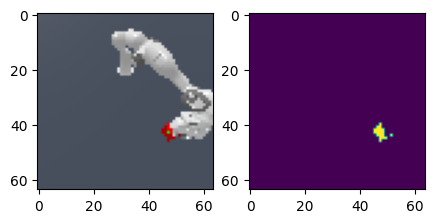

Cube position: [0.09920646 0.26373455 0.0851448 ]
Predicted position: [[ 0.21920848 -0.34301457  0.23604406]]
Pixels in view: 30


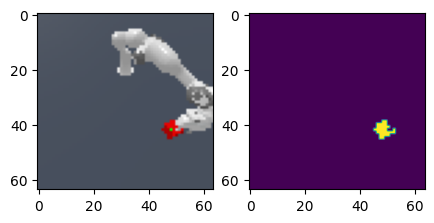

Cube position: [0.10003877 0.24622625 0.08727893]
Predicted position: [[ 0.23374563 -0.29717326  0.21469796]]
Pixels in view: 23


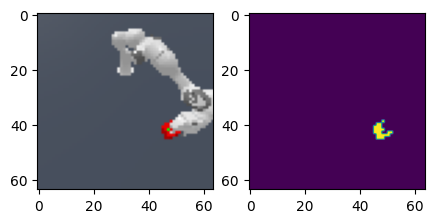

Cube position: [0.10122895 0.2447607  0.09033067]
Predicted position: [[ 0.22991227 -0.21901911  0.21288863]]
Pixels in view: 33


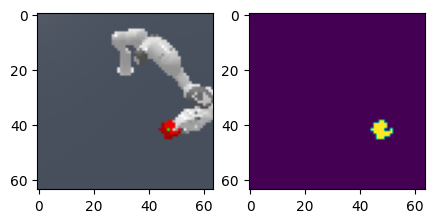

100%|██████████| 1/1 [00:23<00:00, 23.57s/it]


In [10]:
# get first observation from env (reset), feed it to encoder and get feat, feed features to actor for planning sequence, swap features to test out different objects
import utils
%matplotlib inline
from IPython import display
import imageio

newpath = r'./temp' 
if not os.path.exists(newpath):
    os.makedirs(newpath)

render_size = 64
camera = "agentview"

eval_mode = True

agent_state = None
meta = agent.init_meta()

dreamer_obs = eval_env.reset()
episodes = 1

step, episode, total_reward = 0, 0, 0

reward_fn = (
    lambda seq: agent.wm.heads["object_decoder"](
        seq["feat"], only_mlp=True
    )["objects_pos"][0]
    .mean[:, :, 1]
    .unsqueeze(-1)
) 
        
for ep in tqdm(range(episodes)):
    agent_state = None
    dreamer_obs = eval_env.reset()
    
    with torch.no_grad(), utils.eval_mode(agent):
        while not bool(dreamer_obs['is_last']):
            f, axs = plt.subplots(1, 2, figsize=(5, 5))
            action, agent_state = agent.act(
                                    dreamer_obs,
                                    meta,
                                    step,
                                    eval_mode=False,
                                    state=agent_state,
                                )
        
            dreamer_obs = eval_env.step(action)
        
            seg_pixels = np.argwhere(dreamer_obs["segmentation"][0])
            if len(seg_pixels) > 0:
                centroid = np.mean(seg_pixels, axis=0).astype(int)
                dreamer_obs["rgb"][:, centroid[0], centroid[1]] = [0,255,0]

            axs[0].imshow(dreamer_obs["rgb"].transpose(1,2,0))    
            axs[1].imshow(dreamer_obs["segmentation"][0])
            
            pos = dreamer_obs["objects_pos"]
            print(f"Cube position: {pos[0]}")
            # axs[1].set_title(f"{pos[0]}")
            
            feat = agent.wm.rssm.get_feat(agent_state[0]).unsqueeze(0)
            # print(
            predicted_pos = agent.wm.heads["object_decoder"](feat, only_mlp=True)["objects_pos"].mean
            
            print(f"Predicted position: {predicted_pos[0, 0].cpu().numpy()}")
            print(f"Pixels in view: { len(seg_pixels)}")
            
            # contact = eval_env._env.check_contact(eval_env._env.robots[0].gripper, eval_env._env.cube)
            # print(f"Contact: {contact}")
            
            plt.savefig(f'./temp/img_{step}.png', transparent = False, facecolor="white", bbox_inches='tight')
            plt.show()
        
            step += 1
    
    episode += 1
    
    frames = []
    
    for t in range(step):
        image = imageio.v2.imread(f'./temp/img_{t}.png')
        frames.append(image)
        
    imageio.mimsave('./out.gif', # output gif
                frames,          # array of input frames
                fps = 20)  
